In [19]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

# Model to predict the live weight, carcass weight, price, total number of defects
from sklearn.model_selection import cross_validate, KFold
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model to classify defect/no defect
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

In [3]:
RANDOM_STATE = 2210

In [4]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
df_win = pd.read_csv('data/beef_weather_windows.csv')
data =  beef.join(df_win)

# Set up experiments

In [5]:

models = [
    ("Dummy Regressor", "dummy", 0),
    ("ElasticNet", "elasticnet", 30),
    ("SVR", "svr", 20),
    ("Random Forest", "random_forest", 20),
    ("LightGBM", "lightgbm", 30),
    ("Hist Gradient Boosting", "hist_gradient_boosting", 20),
]


def build_model(model_type, params=None):
    params = params or {}

    if model_type == "dummy":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyRegressor(strategy="mean"))
        ])

    if model_type == "elasticnet":
        return Pipeline([
            ("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
            ("scaler", StandardScaler()),
            ("model", ElasticNet(
                alpha=params.get("alpha", 1.0),
                l1_ratio=params.get("l1_ratio", 0.5),
                max_iter=50000,
                random_state=RANDOM_STATE
            ))
        ])

    if model_type == "svr":
        return Pipeline([
            ("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
            ("scaler", StandardScaler()),
            ("model", SVR(
                C=params.get("C", 1.0),
                epsilon=params.get("epsilon", 0.1),
                gamma=params.get("gamma", "scale"),
                kernel="rbf"
            ))
        ])

    if model_type == "random_forest":
        return RandomForestRegressor(
            n_estimators=params.get("n_estimators", 300),
            max_depth=params.get("max_depth"),
            min_samples_leaf=params.get("min_samples_leaf", 1),
            max_features=params.get("max_features", 1.0),
            random_state=RANDOM_STATE,
            n_jobs=1
        )

    if model_type == "lightgbm":
        return LGBMRegressor(
            n_estimators=params.get("n_estimators", 300),
            learning_rate=params.get("learning_rate", 0.05),
            num_leaves=params.get("num_leaves", 31),
            max_depth=params.get("max_depth", -1),
            min_child_samples=params.get("min_child_samples", 20),
            subsample=params.get("subsample", 1.0),
            colsample_bytree=params.get("colsample_bytree", 1.0),
            reg_lambda=params.get("reg_lambda", 0.0),
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1
        )

    if model_type == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            max_iter=params.get("max_iter", 300),
            learning_rate=params.get("learning_rate", 0.05),
            max_leaf_nodes=params.get("max_leaf_nodes", 31),
            l2_regularization=params.get("l2_regularization", 0.0),
            random_state=RANDOM_STATE
        )


def suggest_params(trial, model_type):
    if model_type == "elasticnet":
        return {
            "imputer_strategy": trial.suggest_categorical("imputer_strategy", ["median", "mean"]),
            "alpha": trial.suggest_float("alpha", 1e-4, 50, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.05, 1.0),
        }

    if model_type == "svr":
        return {
            "imputer_strategy": trial.suggest_categorical("imputer_strategy", ["median", "mean"]),
            "C": trial.suggest_float("C", 0.1, 100, log=True),
            "epsilon": trial.suggest_float("epsilon", 0.01, 5, log=True),
            "gamma": trial.suggest_float("gamma", 1e-4, 1, log=True),
        }

    if model_type == "random_forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 500, step=50),
            "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 12]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        }

    if model_type == "lightgbm":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 64),
            "max_depth": trial.suggest_categorical("max_depth", [-1, 3, 5, 8]),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        }

    if model_type == "hist_gradient_boosting":
        return {
            "max_iter": trial.suggest_int("max_iter", 150, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 8, 64),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10, log=True),
        }

    return {}


def tune_model(model_type, X, y, n_trials):
    if n_trials == 0:
        return build_model(model_type), {}

    tuning_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = suggest_params(trial, model_type)
        model = build_model(model_type, params)
        cv = cross_validate(
            model,
            X,
            y,
            cv=tuning_cv,
            scoring="neg_mean_squared_error",
            n_jobs=1
        )
        return -cv["test_score"].mean()

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    return build_model(model_type, study.best_params), study.best_params


In [6]:
# Build splits for windows data.
# Rows are filtered per target, so animals with partial weather records can still be used.

targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade',
                 'Teeth', 'Yield', 'Animal Type_num', 'Grade_num', 'Presentation Grade_num', 'Waste',
                 "price/kg", 'Animal Type', 'max_lag']#, 'Age']

X_full = data.drop(columns=[*drop_features, *targets], errors="ignore")
X_full = X_full.apply(pd.to_numeric, errors="coerce")
Y_full = data[targets].copy()

print("Complete cases:", pd.concat([X_full, Y_full], axis=1).dropna().shape[0])
print("Rows per target:")
display(Y_full.notna().sum().rename("n").to_frame())

Complete cases: 590
Rows per target:


,n
live weight,915
carcass weight,915
price,905
Total number of defects,915


# Run experiments

In [20]:
# # -------------------------------------------------------------------
# # RUN EXPERIMENTS on windows
# # -------------------------------------------------------------------
# out_csv = "results/cv_results_on_animals_windows.csv"
# os.makedirs(os.path.dirname(out_csv), exist_ok=True)

# if os.path.exists(out_csv):
#     os.remove(out_csv)

# scoring = {
#     "MAE": "neg_mean_absolute_error",
#     "MSE": "neg_mean_squared_error",
# }

# cv_obj = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# for model_name, model_type, n_trials in models:
#     for target_name in Y_full.columns:
#         rows = []

#         for atype in ["cow", "steer", "heifer"]:
#             mask = (
#                 data["Animal Type"]
#                 .astype(str)
#                 .str.lower()
#                 .eq(atype)
#                 & Y_full[target_name].notna()
#             )
#             idx = X_full.index[mask]
#             if len(idx) < 5:
#                 continue

#             Xi = X_full.loc[idx]
#             Yi = Y_full.loc[idx, target_name]

#             model, best_params = tune_model(model_type, Xi, Yi, n_trials)

#             cv = cross_validate(
#                 model,
#                 Xi,
#                 Yi,
#                 cv=cv_obj,
#                 scoring=scoring,
#                 return_train_score=True,
#                 n_jobs=1,
#             )

#             rows += [
#                 {
#                     "model_name": model_name,
#                     "animal_type": atype,
#                     "target": target_name,
#                     "measure (MAE/MSE)": m,
#                     "Cross-validation": i + 1,
#                     "evaluated_on (Train/Test)": s.capitalize(),
#                     "Error": -cv[f"{s}_{m}"][i],
#                     "n_rows": len(Xi),
#                     "n_missing_feature_values": int(Xi.isna().sum().sum()),
#                     "best_params": str(best_params),
#                 }
#                 for m in ("MAE", "MSE")
#                 for s in ("train", "test")
#                 for i in range(cv_obj.get_n_splits())
#             ]

#         if rows:
#             pd.DataFrame(rows).to_csv(
#                 out_csv,
#                 mode="a",
#                 index=False,
#                 header=not os.path.exists(out_csv),
#             )

#         print("Completed", model_name, "|", target_name)

# Present results

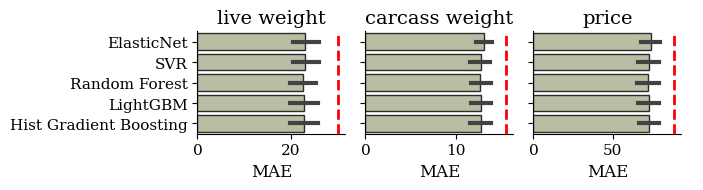

In [20]:
df_res = pd.read_csv("results/cv_results_on_animals_windows.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MAE")].copy()
df_res = df_res[df_res["animal_type"] != "cow"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="bar", y="model_name", col="target", x="Error", 
                sharey=True, sharex=False,color=COLORS[1], alpha=0.8, edgecolor="black", height=2, aspect=1.2)
g.set_axis_labels("MAE", "")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axvline(x=baseline_means[target], color="red", linestyle="--")
    

plt.savefig("figs/meat_pred_modelling.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling.png", dpi=300, bbox_inches="tight")
plt.show()

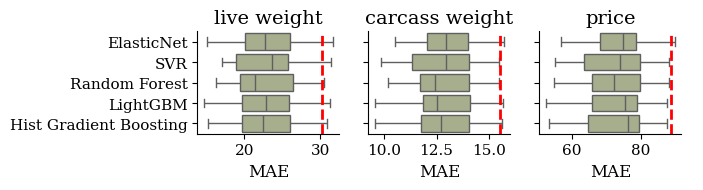

In [21]:
df_res = pd.read_csv("results/cv_results_on_animals_windows.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MAE")].copy()
df_res = df_res[df_res["animal_type"] != "cow"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="box", y="model_name", col="target", x="Error", 
                sharey=True, sharex=False,color=COLORS[1], height=2, aspect=1.2)
g.set_axis_labels("MAE", "")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axvline(x=baseline_means[target], color="red", linestyle="--")
    

plt.savefig("figs/meat_pred_modelling.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling.png", dpi=300, bbox_inches="tight")
plt.show()

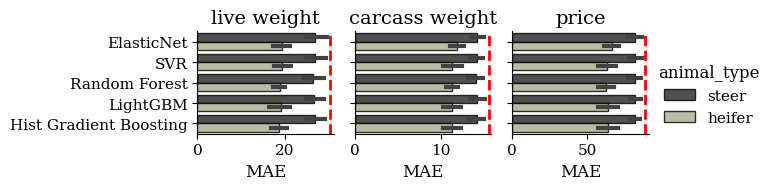

In [23]:
df_res = pd.read_csv("results/cv_results_on_animals_windows.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MAE")].copy()
df_res = df_res[df_res["animal_type"] != "cow"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="bar", y="model_name", col="target", x="Error", 
                hue="animal_type", alpha=0.8, edgecolor="black",
                sharey=True, sharex=False,color=COLORS[1], height=2, aspect=1.2)
g.set_axis_labels("MAE", "")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axvline(x=baseline_means[target], color="red", linestyle="--")
    

plt.savefig("figs/meat_pred_modelling_extended.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling_extended.png", dpi=300, bbox_inches="tight")
plt.show()

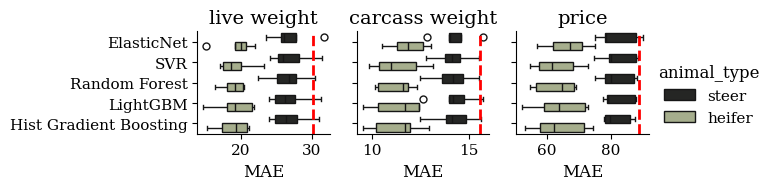

In [24]:
df_res = pd.read_csv("results/cv_results_on_animals_windows.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MAE")].copy()
df_res = df_res[df_res["animal_type"] != "cow"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="box", y="model_name", col="target", x="Error", 
                hue="animal_type",
                sharey=True, sharex=False,color=COLORS[1], height=2, aspect=1.2)
g.set_axis_labels("MAE", "")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axvline(x=baseline_means[target], color="red", linestyle="--")
    

plt.savefig("figs/meat_pred_modelling_extended.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling_extended.png", dpi=300, bbox_inches="tight")
plt.show()

# Classification: predicting animal defects

In [ ]:
# # -------------------------------------------------------------------
# # BINARY CLASSIFICATION: predict whether animal has any defects
# # -------------------------------------------------------------------
# out_csv = "results/cv_results_defect_classification.csv"
# os.makedirs(os.path.dirname(out_csv), exist_ok=True)

# if os.path.exists(out_csv):
#     os.remove(out_csv)

# y_defect = (data["Total number of defects"] > 0).astype(int)

# clf_models = [
#     ("Dummy Classifier", "dummy", 0),
#     ("Logistic Regression", "logistic", 30),
#     ("SVC", "svc", 20),
#     ("Random Forest", "random_forest", 20),
#     ("LightGBM", "lightgbm", 30),
#     ("Hist Gradient Boosting", "hist_gradient_boosting", 20),
# ]

# scoring = {
#     "Accuracy": "accuracy",
#     "Balanced Accuracy": "balanced_accuracy",
#     "F1": "f1",
#     "ROC AUC": "roc_auc",
# }

# for model_name, model_type, n_trials in clf_models:
#     rows = []

#     for atype in ["cow", "steer", "heifer"]:
#         mask = data["Animal Type"].astype(str).str.lower().eq(atype) & data["Total number of defects"].notna()
#         idx = X_full.index[mask]

#         Xi = X_full.loc[idx]
#         Yi = y_defect.loc[idx]

#         min_class_n = Yi.value_counts().min()
#         if Yi.nunique() < 2 or min_class_n < 2:
#             continue

#         cv_obj = StratifiedKFold(n_splits=min(5, min_class_n), shuffle=True, random_state=RANDOM_STATE)

#         def build_clf(params=None):
#             params = params or {}

#             if model_type == "dummy":
#                 return Pipeline([("imputer", SimpleImputer(strategy="median")),
#                                  ("model", DummyClassifier(strategy="most_frequent"))])

#             if model_type == "logistic":
#                 return Pipeline([("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
#                                  ("scaler", StandardScaler()),
#                                  ("model", LogisticRegression(C=params.get("C", 1), penalty="elasticnet",
#                                                               l1_ratio=params.get("l1_ratio", 0.5),
#                                                               solver="saga", max_iter=5000,
#                                                               class_weight="balanced",
#                                                               random_state=RANDOM_STATE))])

#             if model_type == "svc":
#                 return Pipeline([("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
#                                  ("scaler", StandardScaler()),
#                                  ("model", SVC(C=params.get("C", 1), gamma=params.get("gamma", "scale"),
#                                                probability=True, class_weight="balanced",
#                                                random_state=RANDOM_STATE))])

#             if model_type == "random_forest":
#                 return RandomForestClassifier(n_estimators=params.get("n_estimators", 300),
#                                               max_depth=params.get("max_depth"),
#                                               min_samples_leaf=params.get("min_samples_leaf", 1),
#                                               max_features=params.get("max_features", 1.0),
#                                               class_weight="balanced",
#                                               random_state=RANDOM_STATE, n_jobs=1)

#             if model_type == "lightgbm":
#                 return LGBMClassifier(n_estimators=params.get("n_estimators", 300),
#                                       learning_rate=params.get("learning_rate", 0.05),
#                                       num_leaves=params.get("num_leaves", 31),
#                                       max_depth=params.get("max_depth", -1),
#                                       min_child_samples=params.get("min_child_samples", 20),
#                                       class_weight="balanced",
#                                       random_state=RANDOM_STATE, n_jobs=1, verbose=-1)

#             if model_type == "hist_gradient_boosting":
#                 return HistGradientBoostingClassifier(max_iter=params.get("max_iter", 300),
#                                                       learning_rate=params.get("learning_rate", 0.05),
#                                                       max_leaf_nodes=params.get("max_leaf_nodes", 31),
#                                                       l2_regularization=params.get("l2_regularization", 0),
#                                                       random_state=RANDOM_STATE)

#         def suggest_clf_params(trial):
#             if model_type in ["logistic", "svc"]:
#                 params = {"imputer_strategy": trial.suggest_categorical("imputer_strategy", ["median", "mean"]),
#                           "C": trial.suggest_float("C", 0.01, 100, log=True)}
#                 if model_type == "logistic":
#                     params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.05, 1)
#                 else:
#                     params["gamma"] = trial.suggest_float("gamma", 1e-4, 1, log=True)
#                 return params

#             if model_type == "random_forest":
#                 return {"n_estimators": trial.suggest_int("n_estimators", 150, 500, step=50),
#                         "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 12]),
#                         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
#                         "max_features": trial.suggest_float("max_features", 0.3, 1)}

#             if model_type == "lightgbm":
#                 return {"n_estimators": trial.suggest_int("n_estimators", 150, 600, step=50),
#                         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#                         "num_leaves": trial.suggest_int("num_leaves", 8, 64),
#                         "max_depth": trial.suggest_categorical("max_depth", [-1, 3, 5, 8]),
#                         "min_child_samples": trial.suggest_int("min_child_samples", 5, 60)}

#             if model_type == "hist_gradient_boosting":
#                 return {"max_iter": trial.suggest_int("max_iter", 150, 600, step=50),
#                         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#                         "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 8, 64),
#                         "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10, log=True)}

#             return {}

#         if n_trials > 0:
#             def objective(trial):
#                 cv = cross_validate(build_clf(suggest_clf_params(trial)), Xi, Yi, cv=cv_obj,
#                                     scoring="balanced_accuracy", n_jobs=1)
#                 return cv["test_score"].mean()

#             study = optuna.create_study(direction="maximize",
#                                         sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
#             study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
#             model, best_params = build_clf(study.best_params), study.best_params
#         else:
#             model, best_params = build_clf(), {}

#         cv = cross_validate(model, Xi, Yi, cv=cv_obj, scoring=scoring, return_train_score=True, n_jobs=1)

#         rows += [{"model_name": model_name, "animal_type": atype, "target": "has defects",
#                   "measure": m, "Cross-validation": i + 1,
#                   "evaluated_on (Train/Test)": s.capitalize(), "Score": cv[f"{s}_{m}"][i],
#                   "n_rows": len(Xi), "n_defects": int(Yi.sum()), "best_params": str(best_params)}
#                  for m in scoring for s in ("train", "test") for i in range(cv_obj.get_n_splits())]

#     if rows:
#         pd.DataFrame(rows).to_csv(out_csv, mode="a", index=False, header=not os.path.exists(out_csv))

#     print("Completed", model_name)

Completed Dummy Classifier
Completed Logistic Regression
Completed SVC
Completed Random Forest
Completed LightGBM
Completed Hist Gradient Boosting


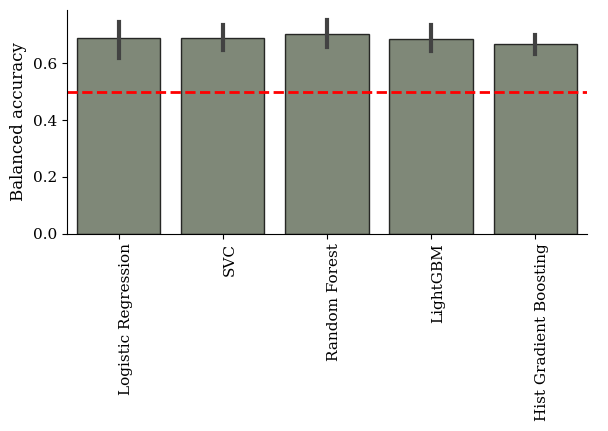

In [25]:
df_clf = pd.read_csv("results/cv_results_defect_classification.csv")
df_clf = df_clf[df_clf["evaluated_on (Train/Test)"].eq("Test")].copy()
df_clf = df_clf[df_clf["measure"].eq("Balanced Accuracy")].copy()
df_clf = df_clf[df_clf["animal_type"] != "cow"].copy()

g = sns.catplot(data=df_clf[df_clf["model_name"] != "Dummy Classifier"], kind="bar",
                x="model_name", y="Score", color=COLORS[0], alpha=0.8,
                edgecolor="black", height=3, aspect=2)

g.set_xticklabels(rotation=90, ha="right", rotation_mode="anchor")
g.set_axis_labels("", "Balanced accuracy")

baseline = df_clf[df_clf["model_name"] == "Dummy Classifier"]["Score"].mean()

for ax in g.axes.flat:
    ax.axhline(y=baseline, color="red", linestyle="--")
    
plt.savefig("figs/meat_pred_modelling_defects.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling_defects.png", dpi=300, bbox_inches="tight")

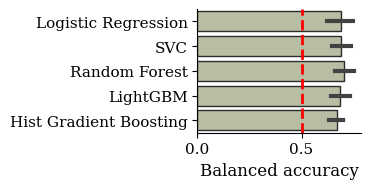

In [27]:
df_clf = pd.read_csv("results/cv_results_defect_classification.csv")
df_clf = df_clf[df_clf["evaluated_on (Train/Test)"].eq("Test")].copy()
df_clf = df_clf[df_clf["measure"].eq("Balanced Accuracy")].copy()
df_clf = df_clf[df_clf["animal_type"] != "cow"].copy()

g = sns.catplot(data=df_clf[df_clf["model_name"] != "Dummy Classifier"], kind="bar",
                y="model_name", x="Score", color=COLORS[1], alpha=0.8,
                edgecolor="black", height=2, aspect=2)

g.set_axis_labels("Balanced accuracy", "")

baseline = df_clf[df_clf["model_name"] == "Dummy Classifier"]["Score"].mean()

for ax in g.axes.flat:
    ax.axvline(x=baseline, color="red", linestyle="--")
    
plt.savefig("figs/meat_pred_modelling_defects.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling_defects.png", dpi=300, bbox_inches="tight")

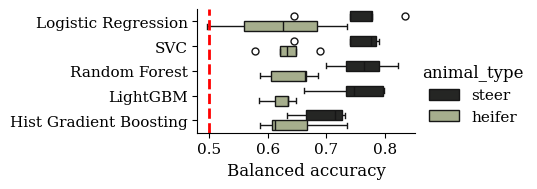

In [31]:
df_clf = pd.read_csv("results/cv_results_defect_classification.csv")
df_clf = df_clf[df_clf["evaluated_on (Train/Test)"].eq("Test")].copy()
df_clf = df_clf[df_clf["measure"].eq("Balanced Accuracy")].copy()
df_clf = df_clf[df_clf["animal_type"] != "cow"].copy()

g = sns.catplot(data=df_clf[df_clf["model_name"] != "Dummy Classifier"], kind="box",
                y="model_name", x="Score", color=COLORS[1], hue="animal_type",
                height=2, aspect=2.5)

g.set_axis_labels("Balanced accuracy", "")

baseline = df_clf[df_clf["model_name"] == "Dummy Classifier"]["Score"].mean()

for ax in g.axes.flat:
    ax.axvline(x=baseline, color="red", linestyle="--")
    
plt.savefig("figs/meat_pred_modelling_defects.svg", bbox_inches="tight")
plt.savefig("figs/meat_pred_modelling_defects.png", dpi=300, bbox_inches="tight")

# Ablation Study

## Regression (live weight, carcass weight, price)

In [8]:
# # -------------------------------------------------------------------
# # ABLATION STUDY: ElasticNet only
# # -------------------------------------------------------------------
# out_csv = "results/cv_results_elasticnet_ablation.csv"
# os.makedirs(os.path.dirname(out_csv), exist_ok=True)

# if os.path.exists(out_csv):
#     os.remove(out_csv)

# weather_features = [c for c in X_full.columns if "__win" in c]
# non_weather_features = [c for c in X_full.columns if c not in weather_features]

# feature_sets = [
#     ("Non-weather only", non_weather_features),
#     ("Weather only", weather_features),
#     ("Non-weather + weather", non_weather_features + weather_features),
# ]

# scoring = {
#     "MAE": "neg_mean_absolute_error",
#     "MSE": "neg_mean_squared_error",
# }

# cv_obj = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# target_list = ["live weight", "carcass weight", "price"]

# for feature_set_name, feature_cols in feature_sets:
#     for target_name in target_list:
#         rows = []

#         for atype in ["steer", "heifer"]:
#             mask = (
#                 data["Animal Type"]
#                 .astype(str)
#                 .str.lower()
#                 .eq(atype)
#                 & Y_full[target_name].notna()
#             )
#             idx = X_full.index[mask]
#             if len(idx) < 5:
#                 continue

#             Xi = X_full.loc[idx, feature_cols]
#             Yi = Y_full.loc[idx, target_name]

#             model, best_params = tune_model("elasticnet", Xi, Yi, 30)

#             cv = cross_validate(
#                 model,
#                 Xi,
#                 Yi,
#                 cv=cv_obj,
#                 scoring=scoring,
#                 return_train_score=True,
#                 n_jobs=1,
#             )

#             rows += [
#                 {
#                     "model_name": "ElasticNet",
#                     "feature_set": feature_set_name,
#                     "animal_type": atype,
#                     "target": target_name,
#                     "measure (MAE/MSE)": m,
#                     "Cross-validation": i + 1,
#                     "evaluated_on (Train/Test)": s.capitalize(),
#                     "Error": -cv[f"{s}_{m}"][i],
#                     "n_rows": len(Xi),
#                     "n_features": len(feature_cols),
#                     "n_missing_feature_values": int(Xi.isna().sum().sum()),
#                     "best_params": str(best_params),
#                 }
#                 for m in ("MAE", "MSE")
#                 for s in ("train", "test")
#                 for i in range(cv_obj.get_n_splits())
#             ]

#         if rows:
#             pd.DataFrame(rows).to_csv(
#                 out_csv,
#                 mode="a",
#                 index=False,
#                 header=not os.path.exists(out_csv),
#             )

#         print("Completed", feature_set_name, "|", target_name)

## Binary classification (defects)

In [9]:
# # -------------------------------------------------------------------
# # ABLATION STUDY: defects classifier, Logistic Regression only
# # -------------------------------------------------------------------
# out_csv = "results/cv_results_defect_ablation.csv"
# os.makedirs(os.path.dirname(out_csv), exist_ok=True)

# if os.path.exists(out_csv):
#     os.remove(out_csv)

# weather_features = [c for c in X_full.columns if "__win" in c]
# non_weather_features = [c for c in X_full.columns if c not in weather_features]

# feature_sets = [
#     ("Non-weather only", non_weather_features),
#     ("Weather only", weather_features),
#     ("Non-weather + weather", non_weather_features + weather_features),
# ]

# y_defect = (data["Total number of defects"] > 0).astype(int)

# scoring = {
#     "Accuracy": "accuracy",
#     "Balanced Accuracy": "balanced_accuracy",
#     "F1": "f1",
#     "ROC AUC": "roc_auc",
# }

# for feature_set_name, feature_cols in feature_sets:
#     rows = []

#     for atype in ["steer", "heifer"]:
#         mask = data["Animal Type"].astype(str).str.lower().eq(atype) & data["Total number of defects"].notna()
#         idx = X_full.index[mask]

#         Xi = X_full.loc[idx, feature_cols]
#         Yi = y_defect.loc[idx]

#         min_class_n = Yi.value_counts().min()
#         if Yi.nunique() < 2 or min_class_n < 2:
#             continue

#         cv_obj = StratifiedKFold(n_splits=min(5, min_class_n), shuffle=True, random_state=RANDOM_STATE)

#         def build_logistic(params=None):
#             params = params or {}
#             return Pipeline([
#                 ("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
#                 ("scaler", StandardScaler()),
#                 ("model", LogisticRegression(C=params.get("C", 1),
#                                               l1_ratio=params.get("l1_ratio", 0.5),
#                                               penalty="elasticnet", solver="saga",
#                                               max_iter=5000, class_weight="balanced",
#                                               random_state=RANDOM_STATE))
#             ])

#         def objective(trial):
#             params = {
#                 "imputer_strategy": trial.suggest_categorical("imputer_strategy", ["median", "mean"]),
#                 "C": trial.suggest_float("C", 0.01, 100, log=True),
#                 "l1_ratio": trial.suggest_float("l1_ratio", 0.05, 1),
#             }
#             cv = cross_validate(build_logistic(params), Xi, Yi, cv=cv_obj,
#                                 scoring="balanced_accuracy", n_jobs=1)
#             return cv["test_score"].mean()

#         study = optuna.create_study(direction="maximize",
#                                     sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
#         study.optimize(objective, n_trials=30, show_progress_bar=False)

#         model = build_logistic(study.best_params)
#         cv = cross_validate(model, Xi, Yi, cv=cv_obj, scoring=scoring,
#                             return_train_score=True, n_jobs=1)

#         rows += [
#             {
#                 "model_name": "Logistic Regression",
#                 "feature_set": feature_set_name,
#                 "animal_type": atype,
#                 "target": "has defects",
#                 "measure": m,
#                 "Cross-validation": i + 1,
#                 "evaluated_on (Train/Test)": s.capitalize(),
#                 "Score": cv[f"{s}_{m}"][i],
#                 "n_rows": len(Xi),
#                 "n_defects": int(Yi.sum()),
#                 "n_features": len(feature_cols),
#                 "n_missing_feature_values": int(Xi.isna().sum().sum()),
#                 "best_params": str(study.best_params),
#             }
#             for m in scoring
#             for s in ("train", "test")
#             for i in range(cv_obj.get_n_splits())
#         ]

#     if rows:
#         pd.DataFrame(rows).to_csv(out_csv, mode="a", index=False,
#                                   header=not os.path.exists(out_csv))

#     print("Completed", feature_set_name)

## Visualizations

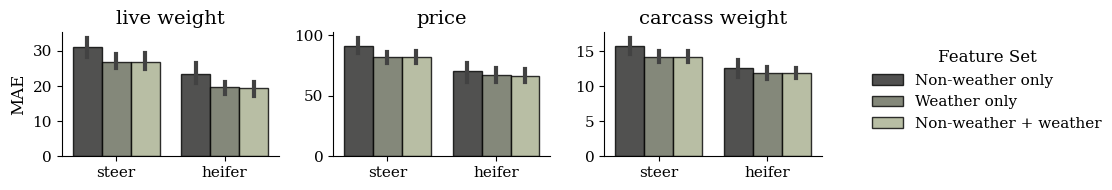

In [32]:
df_ab = pd.read_csv("results/cv_results_elasticnet_ablation.csv")
df_ab = df_ab[df_ab["evaluated_on (Train/Test)"].eq("Test")].copy()
df_ab = df_ab[df_ab["measure (MAE/MSE)"].eq("MAE")].copy()
df_ab = df_ab[df_ab["animal_type"].isin(["steer", "heifer"])].copy()

feature_order = ["Non-weather only", "Weather only", "Non-weather + weather"]

df_ab["feature_set"] = pd.Categorical(df_ab["feature_set"], categories=feature_order, ordered=True)
df_ab = df_ab.sort_values("feature_set")

g = sns.catplot(data=df_ab, kind="bar",
                hue="feature_set", y="Error",
                x="animal_type", col="target",
                sharey=False, color=COLORS[1],
                alpha=0.8, edgecolor="black",
                height=2, aspect=1)

# g.set_xticklabels(rotation=45, ha="right", rotation_mode="anchor")
g.set_axis_labels("", "MAE")

for target, ax in g.axes_dict.items():
    ax.set_title(target)
    
g.figure.subplots_adjust(right=0.78)

g.legend.set_title("Feature Set")
g.legend.set_bbox_to_anchor((1.02, 0.5))
g.legend.set_loc("center left")
g.legend.set_frame_on(False)

plt.tight_layout()
plt.savefig("figs/meat_elasticnet_ablation.svg", bbox_inches="tight")
plt.savefig("figs/meat_elasticnet_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

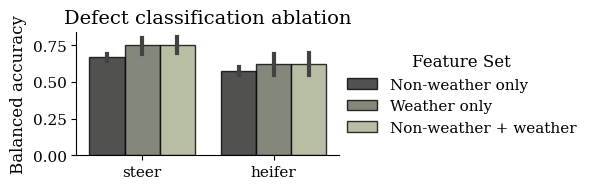

In [33]:
df_ab_clf = pd.read_csv("results/cv_results_defect_ablation.csv")
df_ab_clf = df_ab_clf[df_ab_clf["evaluated_on (Train/Test)"].eq("Test")].copy()
df_ab_clf = df_ab_clf[df_ab_clf["measure"].eq("Balanced Accuracy")].copy()

g = sns.catplot(data=df_ab_clf, kind="bar", hue="feature_set", y="Score",
                x="animal_type", color=COLORS[1], alpha=0.8,
                edgecolor="black", height=2, aspect=2)

g.set_axis_labels("", "Balanced accuracy")
g.legend.set_title("Feature Set")

for ax in g.axes.flat:
    ax.set_title("Defect classification ablation")

plt.savefig("figs/meat_defect_ablation.svg", bbox_inches="tight")
plt.savefig("figs/meat_defect_ablation.png", dpi=300, bbox_inches="tight")
plt.show()


In [26]:
reg = pd.read_csv("results/cv_results_elasticnet_ablation.csv")
reg = reg[(reg["evaluated_on (Train/Test)"] == "Test") & (reg["measure (MAE/MSE)"] == "MAE")]

reg = (reg.groupby(["target", "animal_type", "feature_set"])["Error"].mean()
       .unstack()
       .reset_index())
reg["value"] = (reg["Non-weather + weather"] - reg["Non-weather only"]) / reg["Non-weather only"] * 100
reg["value"] = reg["value"].map(lambda x: f"{x:+.1f}% MAE")

clf = pd.read_csv("results/cv_results_defect_ablation.csv")
clf = clf[(clf["evaluated_on (Train/Test)"] == "Test") & (clf["measure"] == "Balanced Accuracy")]

clf = (clf.groupby(["target", "animal_type", "feature_set"])["Score"].mean()
       .unstack()
       .reset_index())
clf["value"] = (clf["Non-weather + weather"] - clf["Non-weather only"]) / clf["Non-weather only"] * 100
clf["value"] = clf["value"].map(lambda x: f"{x:+.1f}% bAccuracy")

ablation_table = pd.concat([
    reg[["target", "animal_type", "value"]],
    clf[["target", "animal_type", "value"]],
])

ablation_table = ablation_table.pivot(index="target", columns="animal_type", values="value")
ablation_table

animal_type,heifer,steer
target,,
carcass weight,-6.0% MAE,-9.3% MAE
has defects,+7.8% bAccuracy,+12.6% bAccuracy
live weight,-17.1% MAE,-13.5% MAE
price,-5.9% MAE,-10.3% MAE


In [31]:
# tab = ablation_table.copy()
# tab = tab.rename_axis(index="Outcome", columns=None)

# latex = tab.to_latex(
#     column_format="lcc",
#     escape=False,
#     index=True
# )

# print(latex)